# KPI Analysis – Customer Satisfaction

This notebook analyzes customer satisfaction based on review scores and examines how delivery performance is associated with customer reviews.

In [1]:
import pandas as pd
import sys

print("Python:", sys.version)
print("Pandas:", pd.__version__)

Python: 3.13.15 (main, Sep  1 2026, 14:16:48) [MSC v.1944 64 bit (AMD64)]
Pandas: 3.0.5


In [2]:
from pathlib import Path

data_path = Path("../data")

csv_files = list(data_path.glob("*.csv"))

for file in csv_files:
    print(file.name)

In [3]:
from pathlib import Path
print(Path.cwd())

c:\Users\user777\Desktop\Conclusion Intelegence project\SpikupCapstone2026_CYRV\notebooks


In [4]:
data_path = Path("../data")

print("Data folder exists:", data_path.exists())

for item in data_path.iterdir():
    print(item.name)

Data folder exists: True
cyrv
README.md


In [5]:
data_path = Path("../data/cyrv")

csv_files = list(data_path.glob("*.csv"))

for file in csv_files:
    print(file.name)

CYRV_customers_dataset.csv
CYRV_geolocation_dataset.csv
CYRV_orders_dataset.csv
CYRV_order_items_dataset.csv
CYRV_order_payments_dataset.csv
CYRV_order_reviews_dataset.csv
CYRV_products_dataset.csv
CYRV_sellers_dataset.csv
product_category_name_translation.csv


In [6]:
file_info = []

for file in csv_files:
    file_info.append({
        "file": file.name,
        "size_mb": round(file.stat().st_size / (1024 * 1024), 2)
    })

pd.DataFrame(file_info).sort_values("size_mb", ascending=False)

,file,size_mb
1,CYRV_geolocation_dataset.csv,59.39
2,CYRV_orders_dataset.csv,16.93
3,CYRV_order_items_dataset.csv,14.83
5,CYRV_order_reviews_dataset.csv,13.78
0,CYRV_customers_dataset.csv,8.71
4,CYRV_order_payments_dataset.csv,5.61
6,CYRV_products_dataset.csv,2.30
7,CYRV_sellers_dataset.csv,0.17
8,product_category_name_translation.csv,0.00


In [7]:
customers = pd.read_csv(data_path / "CYRV_customers_dataset.csv")
orders = pd.read_csv(data_path / "CYRV_orders_dataset.csv")
order_items = pd.read_csv(data_path / "CYRV_order_items_dataset.csv")
payments = pd.read_csv(data_path / "CYRV_order_payments_dataset.csv")
reviews = pd.read_csv(data_path / "CYRV_order_reviews_dataset.csv")
products = pd.read_csv(data_path / "CYRV_products_dataset.csv")
sellers = pd.read_csv(data_path / "CYRV_sellers_dataset.csv")
category_translation = pd.read_csv(
    data_path / "product_category_name_translation.csv"
)

print("Datasets loaded successfully ✅")

Datasets loaded successfully ✅


In [8]:
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [9]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [10]:
delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

delivered_orders["actual_delivery_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

delivered_orders["delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

delivered_orders["on_time"] = (
    delivered_orders["order_delivered_customer_date"]
    <= delivered_orders["order_estimated_delivery_date"]
)

print("Delivered orders:", len(delivered_orders))
print(
    "Average actual delivery days:",
    round(delivered_orders["actual_delivery_days"].mean(), 2)
)
print(
    "On-time delivery rate:",
    round(delivered_orders["on_time"].mean() * 100, 2),
    "%"
)

Delivered orders: 96478
Average actual delivery days: 12.56
On-time delivery rate: 91.88 %


In [11]:
delivery_reviews = delivered_orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

review_comparison = (
    delivery_reviews
    .groupby("on_time")
    .agg(
        number_of_orders=("order_id", "count"),
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

review_comparison["delivery_status"] = review_comparison["on_time"].map({
    True: "On time",
    False: "Late"
})

review_comparison[
    ["delivery_status", "number_of_orders", "average_review_score"]
]

,delivery_status,number_of_orders,average_review_score
0,Late,7708,2.568500
1,On time,88653,4.293718


In [12]:
delivery_reviews["delivery_status"] = delivery_reviews["on_time"].replace({
    True: "On time",
    False: "Late"
})

review_distribution = pd.crosstab(
    delivery_reviews["review_score"],
    delivery_reviews["delivery_status"],
    normalize="columns"
) * 100

review_distribution.round(2)

delivery_status,Late,On time
review_score,,
1,46.12,6.60
2,7.86,2.63
3,11.35,7.99
4,12.38,20.34
5,22.29,62.43


In [13]:
late_with_reviews = delivery_reviews[
    (delivery_reviews["on_time"] == False) &
    (delivery_reviews["delay_days"].notna())
].copy()

late_with_reviews["delay_group"] = pd.cut(
    late_with_reviews["delay_days"],
    bins=[0, 3, 7, 14, 30, float("inf")],
    labels=["0-3 days", "4-7 days", "8-14 days", "15-30 days", "30+ days"],
    include_lowest=True
)

delay_review_summary = (
    late_with_reviews
    .groupby("delay_group", observed=False)
    .agg(
        number_of_orders=("order_id", "count"),
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

delay_review_summary

,delay_group,number_of_orders,average_review_score
0,0-3 days,2651,3.765372
1,4-7 days,1777,2.316263
2,8-14 days,1758,1.749147
3,15-30 days,1169,1.617622
4,30+ days,345,2.023188


In [14]:
delay_star_distribution = pd.crosstab(
    late_with_reviews["delay_group"],
    late_with_reviews["review_score"],
    normalize="index"
) * 100

delay_star_distribution.round(2)

review_score,1,2,3,4,5
delay_group,,,,,
0-3 days,13.81,5.32,14.52,23.24,43.12
4-7 days,53.01,8.33,10.80,9.74,18.12
8-14 days,67.92,10.07,9.22,4.78,8.02
15-30 days,71.09,10.61,8.90,4.28,5.13
30+ days,64.06,4.64,9.28,8.99,13.04


## Customer Satisfaction Findings

- On-time deliveries received a much higher average review score (4.29) than late deliveries (2.57).
- Customer satisfaction decreases significantly as delivery delays become longer.
- For delays of 0–3 days, 13.81% of reviews were 1-star, compared with 53.01% for delays of 4–7 days and 71.09% for delays of 15–30 days.
- These results indicate a strong relationship between delivery delays and lower customer satisfaction.

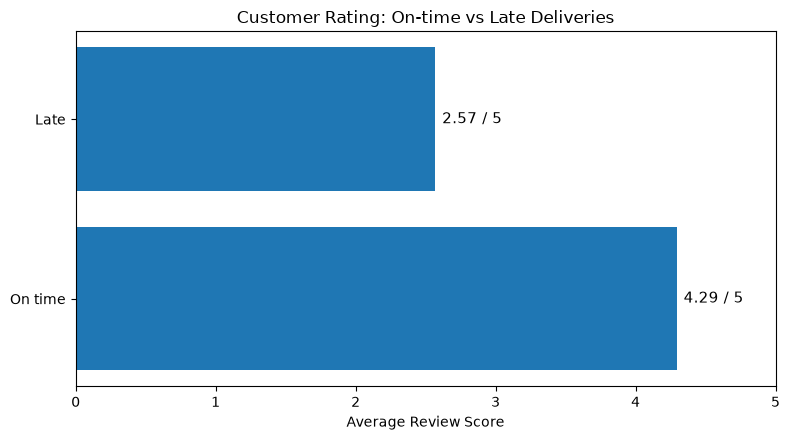

In [15]:
import matplotlib.pyplot as plt

rating_plot = review_comparison[
    ["delivery_status", "average_review_score"]
].copy()

# Put On time first
rating_plot["delivery_status"] = pd.Categorical(
    rating_plot["delivery_status"],
    categories=["On time", "Late"],
    ordered=True
)

rating_plot = rating_plot.sort_values("delivery_status")

plt.figure(figsize=(8, 4.5))

bars = plt.barh(
    rating_plot["delivery_status"],
    rating_plot["average_review_score"]
)

plt.xlim(0, 5)
plt.xlabel("Average Review Score")
plt.ylabel("")
plt.title("Customer Rating: On-time vs Late Deliveries")

for bar, value in zip(bars, rating_plot["average_review_score"]):
    plt.text(
        value + 0.05,
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f} / 5",
        va="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

### Insight

Late deliveries are associated with substantially lower customer satisfaction.  
The average review score drops from **4.29 for on-time deliveries** to **2.57 for late deliveries**.

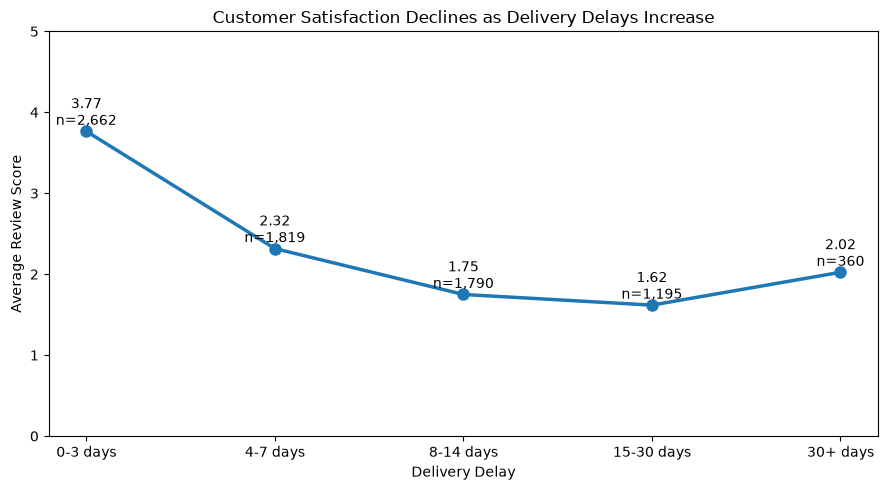

In [21]:
# Number of late orders in each delay group
order_counts = [2662, 1819, 1790, 1195, 360]

plt.figure(figsize=(9, 5))

plt.plot(
    delay_review_summary["delay_group"].astype(str),
    delay_review_summary["average_review_score"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

# Add average rating + number of orders
for x, y, count in zip(
    delay_review_summary["delay_group"].astype(str),
    delay_review_summary["average_review_score"],
    order_counts
):
    plt.text(
        x,
        y + 0.08,
        f"{y:.2f}\nn={count:,}",
        ha="center",
        fontsize=10
    )

plt.ylim(0, 5)
plt.xlabel("Delivery Delay")
plt.ylabel("Average Review Score")
plt.title("Customer Satisfaction Declines as Delivery Delays Increase")

plt.tight_layout()
plt.show()

### Insight

Customer satisfaction declines sharply as delivery delays increase.

- Orders delayed by only 0–3 days still receive an average rating of **3.77**.
- The rating falls to **2.32** for delays of 4–7 days and below **2.0** for delays of 8–30 days.
- The slight increase to **2.02** for delays over 30 days should be interpreted cautiously, as this group contains substantially fewer orders (**n=360**).
- Overall, longer delivery delays are strongly associated with lower customer satisfaction.

### Business Recommendations

- Prioritize on-time delivery, as delivery delays are strongly associated with lower customer satisfaction.
- Monitor orders at risk of delay and intervene early before the customer experience is affected.
- Focus improvement efforts on longer delays, where customer ratings show the strongest decline.
- Use delivery performance together with review scores to identify areas where operational improvements can have the greatest impact on customer satisfaction.